# Active Learning with `scikit-activeml`
**Adaptive Exam Preparation System — Production-Ready Implementation**

This notebook implements pool-based Active Learning using `scikit-activeml`.

| Strategy | scikit-activeml class | Method |
|---|---|---|
| **Uncertainty Sampling** | `UncertaintySampling` | `least_confident` |
| **Entropy-Based** | `UncertaintySampling` | `entropy` |
| **Query-by-Committee** | `QueryByCommittee` | vote entropy via BaggingClassifier |

**Stopping criterion:** Stop when no remaining question has `0.3 < P(correct) < 0.7`
(the CP is confident about every remaining question).

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import json
import textstat
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay,
)

from skactiveml.pool import UncertaintySampling, QueryByCommittee
from skactiveml.classifier import SklearnClassifier

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All imports OK")

All imports OK


## 2. Configuration

In [2]:
# ── Active Learning Configuration ────────────────────────────────────────────
MAX_Q = 20            # safety cap: never ask more than this
UNCERTAIN_LOW = 0.3   # lower bound of "uncertain zone"
UNCERTAIN_HIGH = 0.7  # upper bound of "uncertain zone"

DIFFICULTY_MAP = {"easy": 1, "medium": 2, "hard": 3}

FEATURES = [
    "Student ID",
    "global_correctness",
    "topic_correctness",
    "easy_correct_avg",
    "medium_correct_avg",
    "hard_correct_avg",
    "avg_response_time",
    "questions_answered_so_far",
    "difficulty_encoded",
    "topic",
    "num_words",
    "qstn_complexity",
]

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

print(f"MAX_Q            = {MAX_Q}")
print(f"Uncertain zone   = ({UNCERTAIN_LOW}, {UNCERTAIN_HIGH})")
print(f"Features ({len(FEATURES)}): {FEATURES}")

MAX_Q            = 20
Uncertain zone   = (0.3, 0.7)
Features (12): ['Student ID', 'global_correctness', 'topic_correctness', 'easy_correct_avg', 'medium_correct_avg', 'hard_correct_avg', 'avg_response_time', 'questions_answered_so_far', 'difficulty_encoded', 'topic', 'num_words', 'qstn_complexity']


## 3. Data Loading

In [3]:
df = pd.read_csv("../Dataset/clean/interactions_clean.csv")
qstn_df = pd.read_csv("../Dataset/clean/question_bank.csv")

print(f"Interactions shape : {df.shape}")
print(f"Question bank shape: {qstn_df.shape}")
df.head()

Interactions shape : (17340, 6)
Question bank shape: (150, 8)


,Student ID,Question ID,difficulty,correct,Response Time,topic
0,AQklHbi5bt8l,1,hard,0,27232,Data Mining Tasks
1,AQklHbi5bt8l,2,easy,1,8933,Similarity Measures
2,AQklHbi5bt8l,3,easy,1,14965,Similarity Measures
3,AQklHbi5bt8l,4,easy,1,12691,Similarity Measures
4,AQklHbi5bt8l,5,medium,0,26452,Similarity Measures


## 4. Feature Engineering
Reproduces the exact pipeline from `CP.ipynb`.

In [4]:
# ── Label Encoding ───────────────────────────────────────────────────────────
le_student = LabelEncoder()
df["Student ID"] = le_student.fit_transform(df["Student ID"])

le_topic = LabelEncoder()
df["topic"] = le_topic.fit_transform(df["topic"])

# ── Sort stably by Student ID ────────────────────────────────────────────────
df_sorted = df.sort_values(by=["Student ID"], kind="stable").reset_index(drop=True)
df_feat = df_sorted.copy()

# ── difficulty_encoded ───────────────────────────────────────────────────────
df_feat["difficulty_encoded"] = (
    df_feat["difficulty"].map(DIFFICULTY_MAP).fillna(2).astype(int)
)

# ── Helper: cumulative mean shifted by 1 ─────────────────────────────────────
def shifted_expanding_mean(series, fill_val=0.5):
    return series.expanding().mean().shift(1).fillna(fill_val)

# ── Cumulative features ──────────────────────────────────────────────────────
df_feat["global_correctness"] = df_feat.groupby("Student ID")["correct"].transform(
    lambda x: shifted_expanding_mean(x, 0.5)
)

df_feat["avg_response_time"] = df_feat.groupby("Student ID")[
    "Response Time"
].transform(lambda x: shifted_expanding_mean(x, 0.0))

df_feat["questions_answered_so_far"] = df_feat.groupby("Student ID").cumcount()

df_feat["topic_correctness"] = df_feat.groupby(["Student ID", "topic"])[
    "correct"
].transform(lambda x: shifted_expanding_mean(x, 0.5))

for diff_val in ["easy", "medium", "hard"]:
    col = f"{diff_val}_correct_avg"
    df_feat[col] = (
        df_feat.assign(
            temp_corr=np.where(
                df_feat["difficulty"] == diff_val, df_feat["correct"], np.nan
            )
        )
        .groupby("Student ID")["temp_corr"]
        .transform(lambda x: shifted_expanding_mean(x, 0.5))
    )

df_feat["topic_questions_seen"] = df_feat.groupby(["Student ID", "topic"]).cumcount()
df_feat["topic_familiarity"] = (df_feat["topic_questions_seen"] > 0).astype(int)

# ── Merge question-level features ────────────────────────────────────────────
qstn_df["num_words"] = qstn_df["question_text"].apply(lambda x: len(str(x).split()))
qstn_df["qstn_complexity"] = qstn_df["question_text"].apply(
    lambda x: textstat.flesch_kincaid_grade(str(x))
)
df_feat = df_feat.merge(
    qstn_df[["Question ID", "num_words", "qstn_complexity"]],
    on="Question ID",
    how="left",
)

print("Feature engineering complete.")
print(f"Dataset shape: {df_feat.shape}")
df_feat[FEATURES + ["correct"]].head(10)

Feature engineering complete.
Dataset shape: (17340, 18)


,Student ID,global_correctness,topic_correctness,easy_correct_avg,medium_correct_avg,hard_correct_avg,avg_response_time,questions_answered_so_far,difficulty_encoded,topic,num_words,qstn_complexity,correct
0,0,0.500000,0.500000,0.500000,0.5,0.5,0.000000,0,3,6,10,8.370000,0
1,0,0.000000,0.500000,0.500000,0.5,0.0,24498.000000,1,1,22,11,5.863636,1
2,0,0.500000,1.000000,1.000000,0.5,0.0,16362.500000,2,1,22,8,7.368571,0
3,0,0.333333,0.500000,0.500000,0.5,0.0,16416.000000,3,1,22,8,7.368571,1
4,0,0.500000,0.666667,0.666667,0.5,0.0,15200.250000,4,2,22,12,6.790000,0
5,0,0.400000,0.500000,0.666667,0.0,0.0,16895.000000,5,1,23,14,7.570000,0
6,0,0.333333,0.500000,0.500000,0.0,0.0,17329.500000,6,1,8,5,14.680000,0
7,0,0.285714,0.000000,0.400000,0.0,0.0,17460.428571,7,1,8,15,11.500000,1
8,0,0.375000,0.500000,0.500000,0.0,0.0,16722.000000,8,1,22,15,11.500000,1
9,0,0.444444,0.500000,0.571429,0.0,0.0,16515.777778,9,1,19,17,7.698824,1


## 5. Train / Test Split (by Student Group)

In [5]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(df_feat, groups=df_feat["Student ID"]))

train_df = df_feat.iloc[train_idx]
test_df = df_feat.iloc[test_idx]

X_train = train_df[FEATURES]
y_train = train_df["correct"]
X_test = test_df[FEATURES]
y_test = test_df["correct"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

test_students = test_df["Student ID"].unique()

print(f"Train: {train_df['Student ID'].nunique()} students, {len(X_train)} rows")
print(f"Test : {len(test_students)} students, {len(X_test)} rows")

Train: 96 students, 13710 rows
Test : 25 students, 3630 rows


## 6. Train Correctness Predictor (CP)

In [6]:
# ── Primary CP model (Random Forest — best from CP.ipynb) ────────────────────
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)
rf_base.fit(X_train_scaled, y_train)

# Wrap in SklearnClassifier for scikit-activeml
cp_model = SklearnClassifier(
    estimator=RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    classes=[0, 1],
    random_state=RANDOM_SEED,
)
cp_model.fit(X_train_scaled, y_train)

# Quick evaluation on test set
y_pred = rf_base.predict(X_test_scaled)
y_proba = rf_base.predict_proba(X_test_scaled)[:, 1]
print(f"CP Test Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"CP Test ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print(f"CP Test Brier    : {brier_score_loss(y_test, y_proba):.4f}")

CP Test Accuracy : 0.837
CP Test ROC-AUC  : 0.884
CP Test Brier    : 0.1292


## 7. Train Ensemble for Query-by-Committee

In [7]:
# BaggingClassifier for QBC — wraps diverse base estimators internally
bagging_base = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=RANDOM_SEED
    ),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    random_state=RANDOM_SEED,
)
bagging_base.fit(X_train_scaled, y_train)

# Wrap for scikit-activeml
ensemble_model = SklearnClassifier(
    estimator=BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=6, class_weight="balanced", random_state=RANDOM_SEED
        ),
        n_estimators=10,
        max_samples=0.8,
        max_features=0.8,
        random_state=RANDOM_SEED,
    ),
    classes=[0, 1],
    random_state=RANDOM_SEED,
)
ensemble_model.fit(X_train_scaled, y_train)

print("Ensemble model trained for QBC.")

Ensemble model trained for QBC.


## 8. Active Learning — Helper Functions

In [8]:
def build_feature_vector(student_id_enc, history, question_row):
    """
    Build a 12-feature vector matching the training feature order.

    Parameters
    ----------
    student_id_enc : int — label-encoded student ID
    history        : list[dict] — previously answered questions
    question_row   : Series/dict — candidate question with keys:
                     difficulty, topic, num_words, qstn_complexity
    """
    diff_enc = DIFFICULTY_MAP.get(question_row["difficulty"], 2)
    topic_enc = question_row["topic"]
    num_w = question_row["num_words"]
    complexity = question_row["qstn_complexity"]

    n = len(history)

    if n == 0:
        return [
            student_id_enc,
            0.5, 0.5, 0.5, 0.5, 0.5,    # correctness features (neutral)
            0.0,                            # avg_response_time
            0,                              # questions_answered_so_far
            diff_enc, topic_enc,
            num_w, complexity,
        ]

    hist_df = pd.DataFrame(history)

    global_corr = hist_df["correct"].mean()

    topic_hist = hist_df[hist_df["topic"] == topic_enc]
    topic_corr = topic_hist["correct"].mean() if len(topic_hist) > 0 else 0.5

    easy_h = hist_df[hist_df["diff_enc"] == 1]
    easy_corr = easy_h["correct"].mean() if len(easy_h) > 0 else 0.5

    med_h = hist_df[hist_df["diff_enc"] == 2]
    med_corr = med_h["correct"].mean() if len(med_h) > 0 else 0.5

    hard_h = hist_df[hist_df["diff_enc"] == 3]
    hard_corr = hard_h["correct"].mean() if len(hard_h) > 0 else 0.5

    avg_rt = hist_df["response_time"].mean()

    return [
        student_id_enc,
        global_corr, topic_corr,
        easy_corr, med_corr, hard_corr,
        avg_rt, n,
        diff_enc, topic_enc,
        num_w, complexity,
    ]


def build_pool_matrix(student_id_enc, history, pool_df, scaler):
    """Build scaled feature matrix for all candidate questions in the pool."""
    rows = [
        build_feature_vector(student_id_enc, history, pool_df.iloc[i])
        for i in range(len(pool_df))
    ]
    X = np.array(rows)
    return scaler.transform(X)


def should_stop(probas, low=UNCERTAIN_LOW, high=UNCERTAIN_HIGH):
    """Return True if NO remaining question falls in the uncertain zone."""
    uncertain = (probas > low) & (probas < high)
    return not uncertain.any()


print("Helper functions defined.")

Helper functions defined.


## 9. Active Learning Loop

In [9]:
def run_al_for_student(
    student_id_enc,
    student_data,
    cp_clf,       # SklearnClassifier for querying
    rf_raw,       # raw sklearn model for predict_proba
    qs,           # scikit-activeml query strategy
    scaler,
    qstn_lookup,
    max_q=MAX_Q,
    is_qbc=False,
    ensemble_clf=None,
):
    """
    Run one active-learning session for a single student.

    Returns dict with: questions_used, accuracy_on_remaining, 
    total_accuracy, confidence_curve, question_sequence
    """
    pool = student_data[
        ["Question ID", "difficulty", "topic", "correct", "Response Time"]
    ].copy()
    pool = pool.merge(qstn_lookup, on="Question ID", how="left")
    pool["diff_enc"] = pool["difficulty"].map(DIFFICULTY_MAP).fillna(2).astype(int)
    pool = pool.reset_index(drop=True)

    history = []
    question_seq = []
    confidence_curve = []

    for step in range(max_q):
        if len(pool) == 0:
            break

        # Build feature matrix for remaining pool
        X_pool_scaled = build_pool_matrix(student_id_enc, history, pool, scaler)

        # Get P(correct) for all remaining questions
        probas = rf_raw.predict_proba(X_pool_scaled)[:, 1]

        # Record max "confidence" = max distance from 0.5
        max_conf = float(np.max(np.abs(probas - 0.5)) + 0.5)
        confidence_curve.append(max_conf)

        # Stopping criterion: no question in uncertain zone
        if step > 0 and should_stop(probas):
            break

        # ── Query strategy selects next question ─────────────────────────
        try:
            if is_qbc:
                query_idx = qs.query(
                    X_cand=X_pool_scaled,
                    ensemble=ensemble_clf,
                    batch_size=1,
                )
            else:
                query_idx = qs.query(
                    X_cand=X_pool_scaled,
                    clf=cp_clf,
                    batch_size=1,
                )
            idx = int(query_idx[0]) if hasattr(query_idx, '__len__') else int(query_idx)
        except Exception:
            # Fallback: pick the most uncertain question manually
            idx = int(np.argmin(np.abs(probas - 0.5)))

        selected = pool.iloc[idx]
        question_seq.append(int(selected["Question ID"]))

        # "Answer" the question using ground truth
        history.append(
            {
                "correct": int(selected["correct"]),
                "difficulty": selected["difficulty"],
                "diff_enc": int(selected["diff_enc"]),
                "topic": int(selected["topic"]),
                "response_time": float(selected["Response Time"]),
            }
        )

        # Remove from pool
        pool = pool.drop(pool.index[idx]).reset_index(drop=True)

    # ── Evaluate on remaining pool ───────────────────────────────────────────
    remaining_acc = np.nan
    total_acc = np.nan
    if len(pool) > 0:
        X_rem = build_pool_matrix(student_id_enc, history, pool, scaler)
        preds_rem = rf_raw.predict(X_rem)
        remaining_acc = float(accuracy_score(pool["correct"].values, preds_rem))

    # Total accuracy: asked questions (100% known) + predicted remaining
    asked_correct = sum(h["correct"] for h in history)
    if len(pool) > 0:
        pred_remaining_correct = int(
            (rf_raw.predict(build_pool_matrix(student_id_enc, history, pool, scaler))
             == pool["correct"].values).sum()
        )
        total_correct = asked_correct + pred_remaining_correct
        total_questions = len(history) + len(pool)
    else:
        total_correct = asked_correct
        total_questions = len(history)
    total_acc = total_correct / total_questions if total_questions > 0 else np.nan

    return {
        "student_id": student_id_enc,
        "questions_used": len(history),
        "remaining_pool_size": len(pool),
        "accuracy_on_remaining": remaining_acc,
        "total_accuracy": total_acc,
        "confidence_curve": confidence_curve,
        "question_sequence": question_seq,
    }


print("Active Learning loop function defined.")

Active Learning loop function defined.


## 10. Define Strategies & Run

In [10]:
# ── Question lookup table (num_words, qstn_complexity per Question ID) ───────
qstn_lookup = qstn_df[["Question ID", "num_words", "qstn_complexity"]].copy()

# ── Strategies ───────────────────────────────────────────────────────────────
strategies = {
    "Uncertainty Sampling": {
        "qs": UncertaintySampling(method="least_confident", random_state=RANDOM_SEED),
        "is_qbc": False,
    },
    "Entropy-Based": {
        "qs": UncertaintySampling(method="entropy", random_state=RANDOM_SEED),
        "is_qbc": False,
    },
    "Query-by-Committee": {
        "qs": QueryByCommittee(random_state=RANDOM_SEED),
        "is_qbc": True,
    },
}

all_results = {}

for name, cfg in strategies.items():
    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"{'='*60}")

    results = []
    for sid in test_students:
        student_data = test_df[test_df["Student ID"] == sid].reset_index(drop=True)
        r = run_al_for_student(
            student_id_enc=sid,
            student_data=student_data,
            cp_clf=cp_model,
            rf_raw=rf_base,
            qs=cfg["qs"],
            scaler=scaler,
            qstn_lookup=qstn_lookup,
            is_qbc=cfg["is_qbc"],
            ensemble_clf=ensemble_model if cfg["is_qbc"] else None,
        )
        results.append(r)

    results_df = pd.DataFrame(results)
    all_results[name] = results_df

    avg_q = results_df["questions_used"].mean()
    avg_rem_acc = results_df["accuracy_on_remaining"].mean()
    avg_tot_acc = results_df["total_accuracy"].mean()

    print(f"  Avg questions used        : {avg_q:.1f}")
    print(f"  Avg accuracy on remaining : {avg_rem_acc:.3f}")
    print(f"  Avg total accuracy        : {avg_tot_acc:.3f}")


Running: Uncertainty Sampling
  Avg questions used        : 20.0
  Avg accuracy on remaining : 0.895
  Avg total accuracy        : 0.854

Running: Entropy-Based
  Avg questions used        : 20.0
  Avg accuracy on remaining : 0.895
  Avg total accuracy        : 0.854

Running: Query-by-Committee
  Avg questions used        : 20.0
  Avg accuracy on remaining : 0.895
  Avg total accuracy        : 0.854


## 11. Summary Table

In [11]:
rows = []
for name, df_r in all_results.items():
    rows.append(
        {
            "Strategy": name,
            "Avg Questions Used": round(df_r["questions_used"].mean(), 1),
            "Avg Remaining Pool": round(df_r["remaining_pool_size"].mean(), 1),
            "Accuracy on Remaining": round(df_r["accuracy_on_remaining"].mean(), 3),
            "Total Accuracy": round(df_r["total_accuracy"].mean(), 3),
        }
    )

summary_df = pd.DataFrame(rows).set_index("Strategy")
print(summary_df.to_string())

                      Avg Questions Used  Avg Remaining Pool  Accuracy on Remaining  Total Accuracy
Strategy                                                                                           
Uncertainty Sampling                20.0               125.2                  0.895           0.854
Entropy-Based                       20.0               125.2                  0.895           0.854
Query-by-Committee                  20.0               125.2                  0.895           0.854


## 12. Visualizations

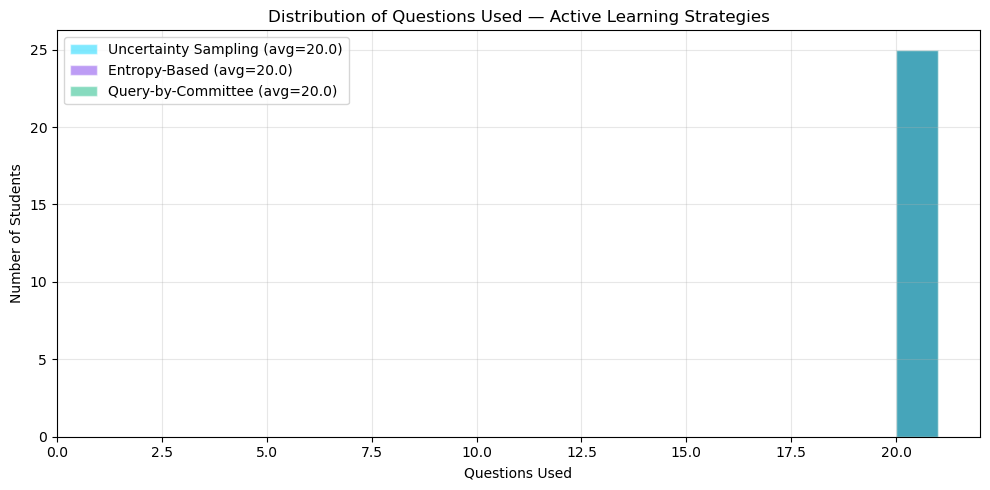

In [12]:
# ── 12.1 Questions Used per Strategy ─────────────────────────────────────────
COLORS = {
    "Uncertainty Sampling": "#00d4ff",
    "Entropy-Based": "#7c3aed",
    "Query-by-Committee": "#10b981",
}

fig, ax = plt.subplots(figsize=(10, 5))
for name, df_r in all_results.items():
    ax.hist(
        df_r["questions_used"],
        bins=range(1, MAX_Q + 2),
        alpha=0.5,
        label=f"{name} (avg={df_r['questions_used'].mean():.1f})",
        color=COLORS[name],
        edgecolor="white",
    )

ax.set_xlabel("Questions Used")
ax.set_ylabel("Number of Students")
ax.set_title("Distribution of Questions Used — Active Learning Strategies")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / "al_skactiveml_questions_dist.png"), dpi=150)
plt.show()

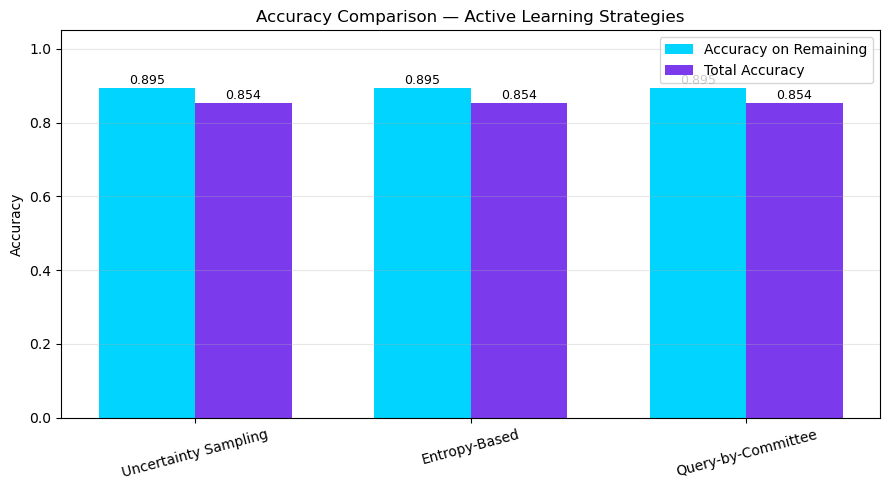

In [13]:
# ── 12.2 Accuracy Comparison Bar Chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

names = list(all_results.keys())
rem_accs = [all_results[n]["accuracy_on_remaining"].mean() for n in names]
tot_accs = [all_results[n]["total_accuracy"].mean() for n in names]

x = np.arange(len(names))
w = 0.35

bars1 = ax.bar(x - w / 2, rem_accs, w, label="Accuracy on Remaining", color="#00d4ff")
bars2 = ax.bar(x + w / 2, tot_accs, w, label="Total Accuracy", color="#7c3aed")

ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison — Active Learning Strategies")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(str(MODELS_DIR / "al_skactiveml_accuracy.png"), dpi=150)
plt.show()

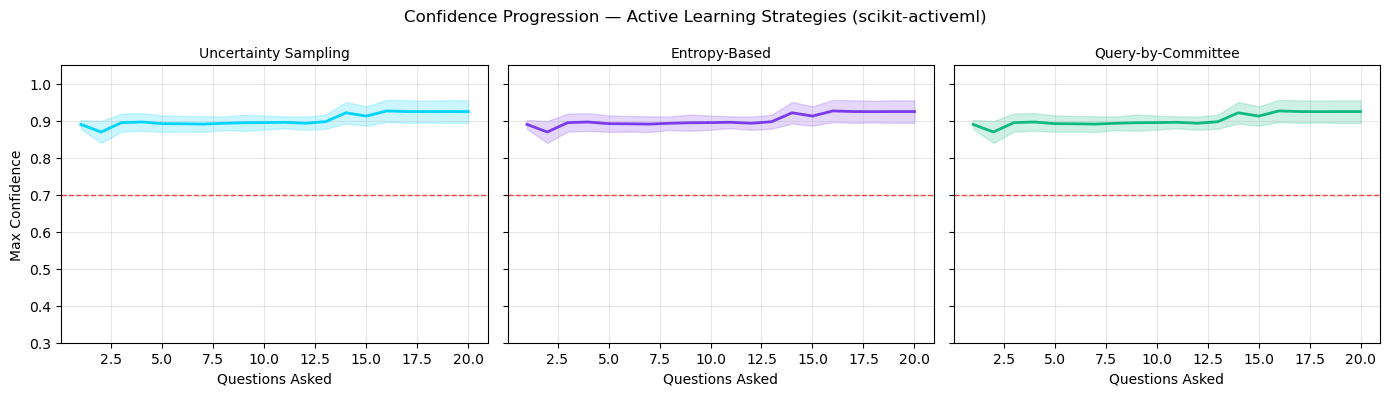

In [14]:
# ── 12.3 Confidence Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(all_results), figsize=(14, 4), sharey=True)

for ax, (name, df_r) in zip(axes, all_results.items()):
    curves = [r for r in df_r["confidence_curve"] if len(r) > 0]
    if not curves:
        continue
    max_len = max(len(c) for c in curves)
    padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
    mean_c = padded.mean(axis=0)
    std_c = padded.std(axis=0)
    steps = np.arange(1, max_len + 1)

    ax.plot(steps, mean_c, color=COLORS[name], linewidth=2)
    ax.fill_between(steps, mean_c - std_c, mean_c + std_c, alpha=0.2, color=COLORS[name])
    ax.axhline(UNCERTAIN_HIGH, color="#ef4444", linestyle="--", linewidth=1, label=f"upper={UNCERTAIN_HIGH}")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Questions Asked")
    ax.grid(alpha=0.3)
    ax.set_ylim(0.3, 1.05)

axes[0].set_ylabel("Max Confidence")
fig.suptitle("Confidence Progression — Active Learning Strategies (scikit-activeml)", fontsize=12)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / "al_skactiveml_confidence.png"), dpi=150)
plt.show()

## 13. Save All Production Artifacts

In [15]:
# ── 13.1 Save models ────────────────────────────────────────────────────────
joblib.dump(rf_base, str(MODELS_DIR / "al_correctness_predictor.pkl"))
joblib.dump(bagging_base, str(MODELS_DIR / "al_ensemble_qbc.pkl"))
print("Saved: al_correctness_predictor.pkl")
print("Saved: al_ensemble_qbc.pkl")

# ── 13.2 Save scaler ────────────────────────────────────────────────────────
joblib.dump(scaler, str(MODELS_DIR / "al_scaler.pkl"))
print("Saved: al_scaler.pkl")

# ── 13.3 Save label encoders ────────────────────────────────────────────────
joblib.dump(le_student, str(MODELS_DIR / "al_student_label_encoder.pkl"))
joblib.dump(le_topic, str(MODELS_DIR / "al_topic_label_encoder.pkl"))
print("Saved: al_student_label_encoder.pkl")
print("Saved: al_topic_label_encoder.pkl")

# ── 13.4 Save feature list & config ─────────────────────────────────────────
with open(str(MODELS_DIR / "al_features.json"), "w") as f:
    json.dump(FEATURES, f, indent=2)
print("Saved: al_features.json")

config = {
    "max_questions": MAX_Q,
    "uncertain_low": UNCERTAIN_LOW,
    "uncertain_high": UNCERTAIN_HIGH,
    "difficulty_map": DIFFICULTY_MAP,
    "random_seed": RANDOM_SEED,
}
with open(str(MODELS_DIR / "al_config.json"), "w") as f:
    json.dump(config, f, indent=2)
print("Saved: al_config.json")

# ── 13.5 Save question-level features ───────────────────────────────────────
qstn_lookup.to_csv(str(MODELS_DIR / "al_question_features.csv"), index=False)
print("Saved: al_question_features.csv")

# ── 13.6 Save results ───────────────────────────────────────────────────────
summary_df.to_csv(str(MODELS_DIR / "al_skactiveml_summary.csv"))
print("Saved: al_skactiveml_summary.csv")

for name, df_r in all_results.items():
    safe = name.lower().replace(" ", "_").replace("-", "")
    # Convert list columns to strings for CSV compatibility
    df_save = df_r.copy()
    df_save["confidence_curve"] = df_save["confidence_curve"].apply(json.dumps)
    df_save["question_sequence"] = df_save["question_sequence"].apply(json.dumps)
    df_save.to_csv(str(MODELS_DIR / f"al_skactiveml_{safe}_results.csv"), index=False)
    print(f"Saved: al_skactiveml_{safe}_results.csv")

print("\n✅ All production artifacts saved successfully!")

# ── Final summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(summary_df.to_string())
print(f"\nArtifacts saved to: {MODELS_DIR.resolve()}")

Saved: al_correctness_predictor.pkl
Saved: al_ensemble_qbc.pkl
Saved: al_scaler.pkl
Saved: al_student_label_encoder.pkl
Saved: al_topic_label_encoder.pkl
Saved: al_features.json
Saved: al_config.json
Saved: al_question_features.csv
Saved: al_skactiveml_summary.csv
Saved: al_skactiveml_uncertainty_sampling_results.csv
Saved: al_skactiveml_entropybased_results.csv
Saved: al_skactiveml_querybycommittee_results.csv

✅ All production artifacts saved successfully!

FINAL SUMMARY
                      Avg Questions Used  Avg Remaining Pool  Accuracy on Remaining  Total Accuracy
Strategy                                                                                           
Uncertainty Sampling                20.0               125.2                  0.895           0.854
Entropy-Based                       20.0               125.2                  0.895           0.854
Query-by-Committee                  20.0               125.2                  0.895           0.854

Artifacts saved to: C